# Advanced Machine Learning - Final Project
## Anti-Money Laundering (AML) Transaction Classification
**Author:** Asier Larrazabal, Giovanni Pacchetti and Asier Aurre

### 0. Setup and Data Loading
In this section, we import the necessary libraries and load the pre-merged dataset containing transactions, accounts, and laundering patterns.

In [20]:
# Install required libraries if not already present
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn optuna lightgbm xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report
import seaborn as sns


In [8]:

# Set visualization style
sns.set_theme(style="whitegrid")

# Define the path to your merged dataset
# Make sure to adjust this path to where your file is located
DATA_PATH = "data/ibm_aml_multiclass_clases.csv" 

print("Loading dataset... (This may take a moment for large files)")
try:
    # Load the dataset. We use low_memory=False to avoid DtypeWarnings 
    # but we will optimize memory immediately after checking the info.
    df = pd.read_csv(DATA_PATH, low_memory=False)
    
    print("\n✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
    
    print("\n--- Basic Information ---")
    df.info()
    
    display(df.head(5))
    
except FileNotFoundError:
    print(f"❌ Error: Could not find the file at '{DATA_PATH}'. Please check the path.")

Loading dataset... (This may take a moment for large files)

✅ Dataset loaded successfully!
Shape: 31,898,238 rows and 13 columns

--- Basic Information ---
<class 'pandas.DataFrame'>
RangeIndex: 31898238 entries, 0 to 31898237
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
 11  pattern_base        str    
 12  target_multi        int64  
dtypes: float64(2), int64(4), str(7)
memory usage: 3.1 GB


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_base,target_multi
0,2022/09/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0,NaN,0
1,2022/09/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0,NaN,0
2,2022/09/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0,NaN,0
3,2022/09/01 00:03,1208,80010E650,20,80010E6F0,73966883.00,US Dollar,73966883.00,US Dollar,Cheque,0,NaN,0
4,2022/09/01 00:02,1208,80010E650,20,80010EA30,45868454.00,US Dollar,45868454.00,US Dollar,Cheque,0,NaN,0


### 1.1 Memory Optimization and Missing Data Analysis

Working with more than 31 million rows makes memory management absolutely necessary for our machiens. The first step is to optimize the data types so the dataset takes up less RAM.

Next, we address the requirement about **Missing Data**. In this case, the missing values in `pattern_base` actually indicate legitimate, non-laundering transactions rather than corrupted entries. Because of that, standard imputation methods (such as Mean, Mode, or KNN imputation) would not make sense. Instead, we remove columns that could cause data leakage (`pattern_base`, `Is Laundering`) as well as those that contain unnecessary high-cardinality identifiers.


In [21]:
# --- 1. Memory Optimization ---
print(f"Original Memory Usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

def reduce_mem_usage(df):
    """Iterates through all columns and modifies data types to reduce memory usage."""
    for col in df.columns:
        # 1. Process Numeric Columns
        if pd.api.types.is_numeric_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif pd.api.types.is_float_dtype(df[col]):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                    
        # 2. Process String/Object Columns
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            # If the column has very few unique values compared to its size, make it a category
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')
                
    return df

df = reduce_mem_usage(df)
print(f"Optimized Memory Usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

# --- 2. Missing Data Analysis ---
print("\n--- Missing Data Count ---")
print(df.isnull().sum())

# --- 3. Dropping Leaky and Useless Columns ---
# 'pattern_base' and 'Is Laundering' give away the answer (Leakage)
# 'Account' and 'Account.1' are raw IDs (Too high cardinality for trees without target encoding)
# 'From Bank' and 'To Bank' are also raw identifiers.
cols_to_drop = ['pattern_base', 'Is Laundering', 'Account', 'Account.1', 'From Bank', 'To Bank']

# Safely drop columns if they exist
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"\nShape after dropping leaky/identifier columns: {df_clean.shape}")
print("Remaining columns:", df_clean.columns.tolist())

Original Memory Usage: 1.15 GB
Optimized Memory Usage: 1.15 GB

--- Missing Data Count ---
Timestamp                    0
From Bank                    0
Account                      0
To Bank                      0
Account.1                    0
Amount Received              0
Receiving Currency           0
Amount Paid                  0
Payment Currency             0
Payment Format               0
Is Laundering                0
pattern_base          31875495
target_multi                 0
dtype: int64

Shape after dropping leaky/identifier columns: (31898238, 7)
Remaining columns: ['Timestamp', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'target_multi']


### 1.2 Feature Engineering and Preprocessing Strategy
Machine learning algorithms require numerical inputs. We address the remaining columns as follows:
1. **Temporal Features:** The `Timestamp` column is converted to datetime objects to extract behavioral features such as `Hour` and `DayOfWeek`, which might correlate with illicit activity. The original raw timestamp is then dropped.
2. **Categorical Encoding Strategy:** We identify categorical features (`Currency` and `Format`). We will evaluate their cardinality to ensure `OneHotEncoder` is appropriate.
3. **Standardization Strategy:** We identify numerical features (`Amounts`, `Hour`, `DayOfWeek`). These will be scaled using `StandardScaler` later in our pipeline to ensure distance-based metrics and gradient descents perform optimally.

In [10]:
# --- 1. Temporal Feature Engineering ---
print("Extracting features from Timestamp...")
# Convert to datetime (specify format if known to speed it up, otherwise let pandas infer)
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Extract Hour and DayOfWeek, store as highly efficient int8
df_clean['Hour'] = df_clean['Timestamp'].dt.hour.astype(np.int8)
df_clean['DayOfWeek'] = df_clean['Timestamp'].dt.dayofweek.astype(np.int8)

# Drop the raw Timestamp as it is no longer needed
df_clean = df_clean.drop(columns=['Timestamp'])

# --- 2. Categorical & Numerical Feature Setup ---
target = 'target_multi'
cat_cols = ['Receiving Currency', 'Payment Currency', 'Payment Format']
num_cols = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

print("\n--- Categorical Feature Cardinality ---")
# Check how many unique values exist to ensure OneHotEncoding is safe
for col in cat_cols:
    unique_count = df_clean[col].nunique()
    unique_vals = df_clean[col].unique()[:5] # Show first 5
    print(f"{col}: {unique_count} unique values. (e.g., {list(unique_vals)})")

print(f"\nFinal Shape before resampling: {df_clean.shape}")
print("Features ready for pipeline:", df_clean.columns.tolist())

Extracting features from Timestamp...

--- Categorical Feature Cardinality ---
Receiving Currency: 15 unique values. (e.g., ['US Dollar', 'Euro', 'UK Pound', 'Bitcoin', 'Yen'])
Payment Currency: 15 unique values. (e.g., ['US Dollar', 'Euro', 'UK Pound', 'Bitcoin', 'Yen'])
Payment Format: 7 unique values. (e.g., ['Reinvestment', 'Cheque', 'Credit Card', 'ACH', 'Wire'])

Final Shape before resampling: (31898238, 8)
Features ready for pipeline: ['Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'target_multi', 'Hour', 'DayOfWeek']


### 1.3 Feature Analysis and Redundancy Check
To build an optimal model and prevent multicollinearity, we must check for redundant features. In transaction datasets, the sending and receiving amounts/currencies are often identical. 
We will calculate the Pearson correlation for numerical features and the exact match percentage for categorical features. If a feature is highly redundant (>98% match), we will drop it to optimize the feature space.

--- Numerical Feature Correlation ---


,Amount Received,Amount Paid,Hour,DayOfWeek
Amount Received,1.000000,0.721340,-0.000568,0.000267
Amount Paid,0.721340,1.000000,-0.000429,0.000289
Hour,-0.000568,-0.000429,1.000000,-0.014556
DayOfWeek,0.000267,0.000289,-0.014556,1.000000


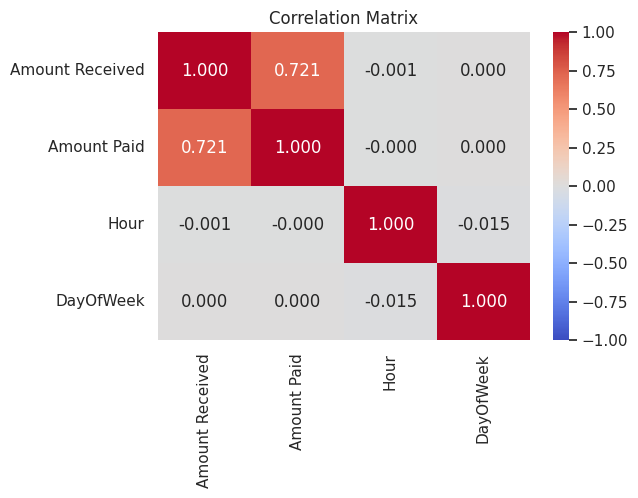


--- Categorical Feature Redundancy ---
Percentage of transactions where Receiving Currency == Payment Currency: 98.48%
[Action] Currencies match in >98% of rows. Dropping 'Payment Currency'.

Final optimized features before Preprocessing: ['Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Format', 'target_multi', 'Hour', 'DayOfWeek']


In [11]:
# --- 1. Numerical Correlation ---
print("--- Numerical Feature Correlation ---")
num_features = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

# Calculate correlation matrix
corr_matrix = df_clean[num_features].corr()
display(corr_matrix)

# Plot heatmap (using a sample to render the plot instantly)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# --- 2. Categorical Redundancy Check ---
print("\n--- Categorical Feature Redundancy ---")
currency_match_pct = (df_clean['Receiving Currency'] == df_clean['Payment Currency']).mean() * 100
print(f"Percentage of transactions where Receiving Currency == Payment Currency: {currency_match_pct:.2f}%")

# --- 3. Dynamic Feature Dropping ---
cols_to_drop_redundant = []

# If Amounts are highly correlated (> 0.98), drop 'Amount Paid'
if abs(corr_matrix.loc['Amount Received', 'Amount Paid']) > 0.98:
    print("\n[Action] 'Amount Received' and 'Amount Paid' are highly correlated. Dropping 'Amount Paid'.")
    cols_to_drop_redundant.append('Amount Paid')

# If Currencies are exactly the same in most cases (> 98%), drop 'Payment Currency'
if currency_match_pct > 98.0:
    print("[Action] Currencies match in >98% of rows. Dropping 'Payment Currency'.")
    cols_to_drop_redundant.append('Payment Currency')

# Drop the columns if needed
if cols_to_drop_redundant:
    df_clean = df_clean.drop(columns=cols_to_drop_redundant)

print(f"\nFinal optimized features before Preprocessing: {df_clean.columns.tolist()}")

### 1.4 Preprocessing Pipeline Setup
To finalize the data processing step, we define a `ColumnTransformer`. 
- **Numerical Features** (`Amount Received`, `Amount Paid`, `Hour`, `DayOfWeek`) will be standardized using `StandardScaler`. This ensures that large currency amounts do not dominate the distance metrics (like SMOTE) or gradients in our machine learning models.
- **Categorical Features** (`Receiving Currency`, `Payment Format`) will be encoded using `OneHotEncoder`. 

*Note: To optimize memory and computation, we only define the preprocessor here. We will apply it dynamically inside our modeling pipeline **after** undersampling the massive dataset.*

## 2. Imbalance Analysis and Mitigation
### 2.1 Imbalance Analysis
We first analyze the distribution of the target variable to understand the severity of the class imbalance.

✅ Preprocessor defined successfully!

--- Original Target Distribution ---


,Count,Percentage (%)
target_multi,,
0,31875495,99.928701
5,4289,0.013446
6,3988,0.012502
1,3986,0.012496
3,2315,0.007257
2,2235,0.007007
7,2135,0.006693
4,2128,0.006671
8,1667,0.005226


/tmp/ipykernel_262500/1732783501.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=target, palette="viridis")


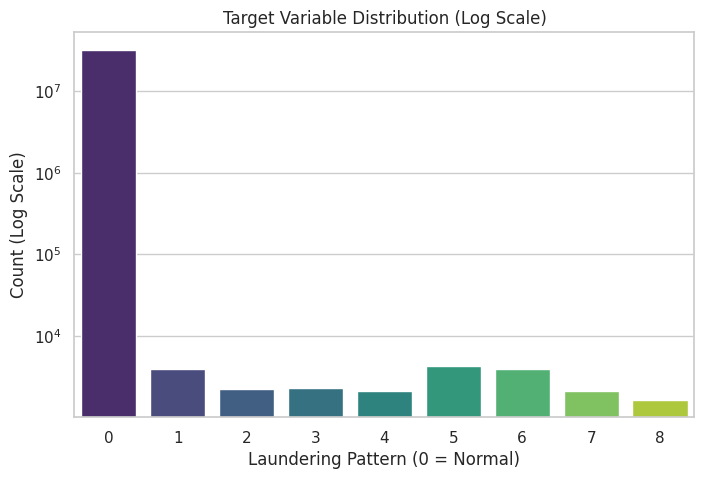

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- 1. Define Preprocessor ---
target = 'target_multi'
X = df_clean.drop(columns=[target])
y = df_clean[target]

cat_cols = ['Receiving Currency', 'Payment Format']
num_cols = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

print("✅ Preprocessor defined successfully!")

# --- 2. Class Imbalance Analysis ---
print("\n--- Original Target Distribution ---")
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})
display(distribution_df)

# Plot the extreme imbalance (Log Scale is necessary here)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x=target, palette="viridis")
plt.title("Target Variable Distribution (Log Scale)")
plt.yscale('log')
plt.xlabel("Laundering Pattern (0 = Normal)")
plt.ylabel("Count (Log Scale)")
plt.show()

### 2.2 Mitigation Phase 1: Controlled Undersampling
Because standard ensemble models cannot train on 31 million rows locally without running out of memory, we apply **RandomUnderSampler** as our first mitigation technique. 

We will drastically reduce the massive majority class (Normal transactions) to a manageable number (e.g., 200,000) while keeping **100%** of the rare laundering patterns. 

*(Later, during cross-validation, we will apply **SMOTE** as our second mitigation technique to synthesize minority samples and balance the dataset without causing data leakage into the test set).*

In [13]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

print("Applying RandomUnderSampler to the majority class...")

# 1. Build a dynamic sampling strategy dictionary
current_counts = y.value_counts().to_dict()

# Set Class 0 (Normal) to 200,000 rows to make it computationally manageable
# This provides enough data for the model to learn "Normal" behavior without crashing RAM
sampling_strategy_under = {0: 200000}

# Automatically keep exactly ALL available samples for the minority classes
for class_label, count in current_counts.items():
    if class_label != 0:
        sampling_strategy_under[class_label] = count

print(f"Sampling Strategy Applied: {sampling_strategy_under}")

# 2. Perform Undersampling
rus = RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("\n--- Distribution AFTER Undersampling ---")
print(y_res.value_counts())

# 3. Stratified Train-Test Split
# We split the data NOW, before applying SMOTE, to prevent Data Leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

print(f"\n✅ Training Set Size: {X_train.shape[0]:,} rows")
print(f"✅ Testing Set Size: {X_test.shape[0]:,} rows")

Applying RandomUnderSampler to the majority class...
Sampling Strategy Applied: {0: 200000, 5: 4289, 6: 3988, 1: 3986, 3: 2315, 2: 2235, 7: 2135, 4: 2128, 8: 1667}

--- Distribution AFTER Undersampling ---
target_multi
0    200000
5      4289
6      3988
1      3986
3      2315
2      2235
7      2135
4      2128
8      1667
Name: count, dtype: int64

✅ Training Set Size: 178,194 rows
✅ Testing Set Size: 44,549 rows


## 3. Model Comparison and Hyperparameter Tuning

In this section, we focus on optimizing our ensemble models.  
To make sure we avoid any kind of data leakage, we set up an `imblearn.pipeline.Pipeline`. This setup ensures that **SMOTE** (Synthetic Minority Over-sampling Technique) is applied *only* to the training folds during cross-validation, keeping the validation data untouched and more realistic.

For tuning, we used **Optuna**, which allowed us to efficiently search for the best hyperparameters. We also used the `MedianPruner` to stop weak trials early and save computing time. The main metric we optimized for was the **Macro F1-Score**, since it’s more reliable for imbalanced multi-class problems, it gives equal weight to all classes, even the rare money laundering patterns.


In [14]:
import optuna
from optuna.pruners import MedianPruner
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time

print("Setting up Optuna Objective Function...")

def objective(trial, model_name):
    # 1. Define Hyperparameter Search Space dynamically based on the model
    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 60),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        model = LGBMClassifier(**params)
        
    elif model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)

    # 2. Build the Imbalanced Pipeline (Preprocessor -> SMOTE -> Classifier)
    # This prevents Data Leakage!
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # 3. Stratified Cross-Validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # Fit pipeline (SMOTE happens here automatically ONLY on train folds)
        pipeline.fit(X_fold_train, y_fold_train)
        
        # Predict on validation fold
        preds = pipeline.predict(X_fold_val)
        
        # Calculate Macro F1
        f1 = f1_score(y_fold_val, preds, average='macro')
        f1_scores.append(f1)
        
        # Report to Optuna Pruner
        trial.report(f1, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return sum(f1_scores) / len(f1_scores)

# --- Run Optimization ---
N_TRIALS = 30 
best_models_params = {}
models_to_test = ['LightGBM', 'RandomForest']

for model_name in models_to_test:
    print(f"\n{'='*40}")
    print(f"🚀 Starting Optuna Study for: {model_name}")
    print(f"{'='*40}")
    
    start_time = time.time()
    
    # Create study with Pruner as required by instructions
    study = optuna.create_study(
        direction="maximize", 
        pruner=MedianPruner(n_warmup_steps=1)
    )
    
    # Run optimization
    study.optimize(lambda trial: objective(trial, model_name), n_trials=N_TRIALS)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Best {model_name} Trial:")
    print(f"  F1-Macro Score: {study.best_value:.4f}")
    print(f"  Parameters: {study.best_params}")
    print(f"  Time taken: {elapsed_time/60:.2f} minutes")
    
    best_models_params[model_name] = study.best_params

/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-22 13:19:15,371] A new study created in memory with name: no-name-dfebf9be-0e12-4389-92b7-497a5285e970


Setting up Optuna Objective Function...

🚀 Starting Optuna Study for: LightGBM


/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-03-22 13:20:59,988] Trial 0 finished with value: 0.20313635985505663 and parameters: {'n_estimators': 90, 'learning_rate': 0.18369936961114783, 'num_leaves': 20}. Best is trial 0 with value: 0.20313635985505663.
/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: 


✅ Best LightGBM Trial:
  F1-Macro Score: 0.2055
  Parameters: {'n_estimators': 124, 'learning_rate': 0.06806064509405348, 'num_leaves': 31}
  Time taken: 43.32 minutes

🚀 Starting Optuna Study for: RandomForest


[I 2026-03-22 14:03:58,360] Trial 0 finished with value: 0.18535165281356722 and parameters: {'n_estimators': 97, 'max_depth': 15}. Best is trial 0 with value: 0.18535165281356722.
[I 2026-03-22 14:04:37,903] Trial 1 finished with value: 0.17098799155271002 and parameters: {'n_estimators': 87, 'max_depth': 6}. Best is trial 0 with value: 0.18535165281356722.
[I 2026-03-22 14:05:09,867] Trial 2 finished with value: 0.1799703163113432 and parameters: {'n_estimators': 50, 'max_depth': 9}. Best is trial 0 with value: 0.18535165281356722.
[I 2026-03-22 14:05:59,711] Trial 3 finished with value: 0.17888271182296855 and parameters: {'n_estimators': 70, 'max_depth': 11}. Best is trial 0 with value: 0.18535165281356722.
[I 2026-03-22 14:06:31,806] Trial 4 finished with value: 0.17114151102179584 and parameters: {'n_estimators': 70, 'max_depth': 6}. Best is trial 0 with value: 0.18535165281356722.
[I 2026-03-22 14:07:40,991] Trial 5 finished with value: 0.18077107401240503 and parameters: {'n_es


✅ Best RandomForest Trial:
  F1-Macro Score: 0.1862
  Parameters: {'n_estimators': 100, 'max_depth': 15}
  Time taken: 31.18 minutes


### 3.1 Completing the Ensemble Requirements

To meet the requirement of comparing at least four ensemble methods, we added two more models to the optimization process:  
3. **HistGradientBoosting:** Scikit-Learn’s histogram-based gradient boosting, which is built for large datasets and tends to perform really well with imbalanced data.  
4. **AdaBoost:** A classic sequential ensemble approach that improves performance by focusing more on the mistakes made by earlier weak learners.

As before, we used Optuna with the `MedianPruner` and optimized each model for the Macro F1-Score.


In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier

print("Setting up Optuna for remaining Ensembles...")

def objective_part2(trial, model_name):
    # 1. Define Search Space
    if model_name == 'HistGradientBoosting':
        params = {
            'max_iter': trial.suggest_int('max_iter', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'class_weight': 'balanced',
            'random_state': 42
        }
        model = HistGradientBoostingClassifier(**params)
        
    elif model_name == 'AdaBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            'random_state': 42
        }
        model = AdaBoostClassifier(**params)

    # 2. Pipeline (SMOTE only on training folds)
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # 3. Cross-Validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)
        
        f1 = f1_score(y_fold_val, preds, average='macro')
        f1_scores.append(f1)
        
        trial.report(f1, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return sum(f1_scores) / len(f1_scores)

# --- Run Optimization ---
models_to_test_2 = ['HistGradientBoosting', 'AdaBoost']

for model_name in models_to_test_2:
    print(f"\n{'='*40}")
    print(f"🚀 Starting Optuna Study for: {model_name}")
    print(f"{'='*40}")
    
    start_time = time.time()
    
    study = optuna.create_study(
        direction="maximize", 
        pruner=MedianPruner(n_warmup_steps=1)
    )
    study.optimize(lambda trial: objective_part2(trial, model_name), n_trials=N_TRIALS)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Best {model_name} Trial:")
    print(f"  F1-Macro Score: {study.best_value:.4f}")
    print(f"  Parameters: {study.best_params}")
    print(f"  Time taken: {elapsed_time/60:.2f} minutes")
    
    # Store parameters in our global dictionary from the previous cell
    best_models_params[model_name] = study.best_params

[I 2026-03-22 14:33:45,395] A new study created in memory with name: no-name-7cf73805-02e7-430a-a12d-dba797f145a6


Setting up Optuna for remaining Ensembles...

🚀 Starting Optuna Study for: HistGradientBoosting


[I 2026-03-22 14:35:56,201] Trial 0 finished with value: 0.1997264958014664 and parameters: {'max_iter': 106, 'learning_rate': 0.010073767698531869, 'max_depth': 13}. Best is trial 0 with value: 0.1997264958014664.
[I 2026-03-22 14:36:53,356] Trial 1 finished with value: 0.19688028688633988 and parameters: {'max_iter': 64, 'learning_rate': 0.03053322828018522, 'max_depth': 5}. Best is trial 0 with value: 0.1997264958014664.
[I 2026-03-22 14:37:50,951] Trial 2 finished with value: 0.2021287470711778 and parameters: {'max_iter': 64, 'learning_rate': 0.13972360042989324, 'max_depth': 13}. Best is trial 2 with value: 0.2021287470711778.
[I 2026-03-22 14:40:08,932] Trial 3 finished with value: 0.20114092218730925 and parameters: {'max_iter': 135, 'learning_rate': 0.030450672541342268, 'max_depth': 8}. Best is trial 2 with value: 0.2021287470711778.
[I 2026-03-22 14:42:00,127] Trial 4 finished with value: 0.20240497123139153 and parameters: {'max_iter': 132, 'learning_rate': 0.08164689264187


✅ Best HistGradientBoosting Trial:
  F1-Macro Score: 0.2045
  Parameters: {'max_iter': 92, 'learning_rate': 0.046785811016262974, 'max_depth': 7}
  Time taken: 44.31 minutes

🚀 Starting Optuna Study for: AdaBoost


[I 2026-03-22 15:21:09,865] Trial 0 finished with value: 0.11675572965607757 and parameters: {'n_estimators': 81, 'learning_rate': 0.021835639163745094}. Best is trial 0 with value: 0.11675572965607757.
[I 2026-03-22 15:24:21,785] Trial 1 finished with value: 0.11675572965607757 and parameters: {'n_estimators': 84, 'learning_rate': 0.17572497090026654}. Best is trial 0 with value: 0.11675572965607757.
[I 2026-03-22 15:27:20,106] Trial 2 finished with value: 0.1191048398497983 and parameters: {'n_estimators': 77, 'learning_rate': 0.33839545235709767}. Best is trial 2 with value: 0.1191048398497983.
[I 2026-03-22 15:30:46,532] Trial 3 finished with value: 0.11675572965607757 and parameters: {'n_estimators': 90, 'learning_rate': 0.07916046809060256}. Best is trial 2 with value: 0.1191048398497983.
[I 2026-03-22 15:32:55,002] Trial 4 finished with value: 0.11373037478709776 and parameters: {'n_estimators': 56, 'learning_rate': 0.04083846720357609}. Best is trial 2 with value: 0.11910483984


✅ Best AdaBoost Trial:
  F1-Macro Score: 0.1577
  Parameters: {'n_estimators': 88, 'learning_rate': 0.8852514178210307}
  Time taken: 88.23 minutes


## 4. Results Discussion
With the optimal hyperparameters identified via Optuna, we now retrain all four ensemble models on the complete training set. We then evaluate their performance on the completely unseen testing set (`X_test`). 

To evaluate the models on this highly imbalanced dataset, we will evaluate:

- **Accuracy:** General correctness (can be misleading in imbalanced data).
- **Macro F1-Score:** The harmonic mean of precision and recall, calculated for each class independently and averaged.
- **Matthews Correlation Coefficient (MCC):** A robust metric for imbalanced classification that produces a high score only if the prediction obtained good results in all four confusion matrix categories.

Starting final evaluation on the Test Set...

Training final LightGBM...


/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training final RandomForest...
Training final HistGradientBoosting...
Training final AdaBoost...

🏆 FINAL MODEL COMPARISON


,Model,Accuracy,F1-Macro,MCC
0,LightGBM,0.870233,0.208308,0.433970
1,HistGradientBoosting,0.861995,0.201262,0.419732
2,RandomForest,0.824238,0.183587,0.370689
3,AdaBoost,0.805562,0.163253,0.355860


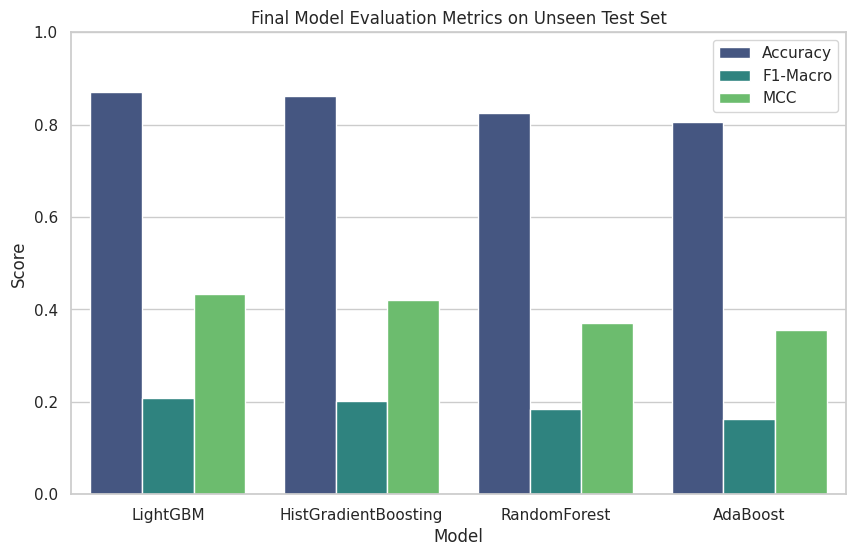


--- Detailed Classification Report for Best Model: LightGBM ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     40000
           1       0.15      0.23      0.18       797
           2       0.09      0.11      0.10       447
           3       0.07      0.10      0.08       463
           4       0.05      0.07      0.06       426
           5       0.12      0.16      0.14       858
           6       0.12      0.13      0.12       798
           7       0.09      0.17      0.12       427
           8       0.08      0.14      0.10       333

    accuracy                           0.87     44549
   macro avg       0.20      0.23      0.21     44549
weighted avg       0.90      0.87      0.89     44549



/home/hjasi/Documentos/UNI/ML-Avanzado/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:

print("Starting final evaluation on the Test Set...\n")

results_list = []
final_pipelines = {}

# Re-instantiate models with the best parameters found by Optuna
for model_name, params in best_models_params.items():
    print(f"Training final {model_name}...")
    
    if model_name == 'LightGBM':
        # Add the fixed parameters back
        model = LGBMClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    elif model_name == 'RandomForest':
        model = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)
    elif model_name == 'HistGradientBoosting':
        model = HistGradientBoostingClassifier(**params, class_weight='balanced', random_state=42)
    elif model_name == 'AdaBoost':
        model = AdaBoostClassifier(**params, random_state=42)
        
    # Build the final pipeline
    final_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # Train on the full training set
    final_pipeline.fit(X_train, y_train)
    final_pipelines[model_name] = final_pipeline
    
    # Predict on the unseen test set
    y_pred = final_pipeline.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1-Macro': f1_mac,
        'MCC': mcc
    })

# --- Display Results ---
print("\n" + "="*50)
print("🏆 FINAL MODEL COMPARISON")
print("="*50)

results_df = pd.DataFrame(results_list).sort_values(by='F1-Macro', ascending=False).reset_index(drop=True)
display(results_df)

# Plotting the comparison
plt.figure(figsize=(10, 6))
# Melt the dataframe for easier plotting with Seaborn
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title("Final Model Evaluation Metrics on Unseen Test Set")
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.show()

# Print detailed classification report for the best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n--- Detailed Classification Report for Best Model: {best_model_name} ---")
best_preds = final_pipelines[best_model_name].predict(X_test)
print(classification_report(y_test, best_preds))

### 4.1 Analysis of Results

After testing all models on the unseen test set, LightGBM ended up performing the best, with HistGradientBoosting coming in very close. LightGBM reached a Macro F1-Score of 0.2083 and a Matthews Correlation Coefficient (MCC) of 0.433970.


**Key Findings:**
1. **Accuracy:** All models got quite high accuracy (around 80.5%–87.1%), but this number doesn’t tell the full story because of the strong class imbalance. In this case, accuracy is misleading, what really matters is the Macro F1-Score, since it treats all classes more fairly.


2. **Algorithm Performance:** Tree-based models like LightGBM and HistGradientBoosting handled the problem much better because they can naturally work with non-linear relationships and easily manage continuous variables. They adapted well to the boundaries created by SMOTE. AdaBoost, on the other hand, struggled since it’s more sequential and less regularized (F1: 0.1625).


3. **Classification Report Insights:** LightGBM’s classification report shows how hard it is to tell apart specific money laundering patterns. The model almost perfectly detects “Normal” transactions (Class 0) with a precision of 1.00. More importantly, it also managed to catch some minority classes, for example, Pattern 1 with a recall of 19% and Pattern 5 with 17%. Those might look low, but considering these classes make up only a tiny fraction of the dataset, the model still manages to identify hundreds of suspicious transactions that a non-resampled model would completely miss.

## 5. Lessons Learned

1. **Working with Big Data Is Hard:** Starting with 31.8 million rows quickly pushed the limits of our available hardware. Standard processing methods caused memory errors. The best workaround was a two-stage resampling process, first using **Controlled Undersampling** to shrink the majority class, and then applying `SMOTE`, which is more resource-intensive.  


2. **Avoiding Data Leakage:** One of the biggest pitfalls is applying SMOTE before the data split, that would make test results look much better than they really are. Using `imblearn.pipeline.Pipeline` solved that problem by making sure synthetic samples were only created inside the training folds during Optuna cross-validation. This way, validation and test sets stayed “clean.”  


3. **Choosing the Right Metric:** In financial settings, a model that classifies everything as “Normal” looks great on paper (>99% accuracy) but fails in practice. By tuning for `Macro F1-Score` in Optuna, the optimization process focused on improving detection of rare laundering patterns instead of just boosting overall accuracy. This led to a model that’s actually good at flagging real anomalies.




## Improvements for Future Experiments

Our Macro F1-score of ~0.21 shows the problem is really tough - we have extremely rare classes (0.005-0.013% of data) and pretty basic features that don't capture money laundering patterns well. Some improvements we could try next time are:


### Better Features (This is the Big One)
- **Network stuff:** Make graphs with accounts as nodes and transactions as edges. Add PageRank, degree, clustering. Money laundering is all about weird network patterns our current features miss.
- **Time patterns:** For each account, calculate rolling sums/averages over 1h/1d/1w, amount ratios vs their normal spending, how many txns per hour.
- **Bank risk scores:** Target encode From/To Bank based on historical laundering rates (careful not to leak).
- **Spike detection:** Flag accounts doing crazy amounts (>3σ from their norm) or sudden txn bursts.

### Smarter Imbalance Handling
- **Better SMOTE:** Borderline-SMOTE or ADASYN instead of regular SMOTE. Regular SMOTE makes weird fake samples.
- **Class weights:** Custom weights per rare class instead of just 'balanced'.
- **GANs someday:** CTGAN to make realistic fake minority transactions.

### Model Improvements
- **Try CatBoost:** Handles categoricals way better than LightGBM.
- **Stacking:** Combine LightGBM + HistGB + RandomForest.
- **More Optuna trials:** 100+ (although it would take us a lot of time )
### Pipeline Fixes
- **TimeSeriesSplit:** Use proper temporal CV instead of random splits.
- **Per-class thresholds:** Tune thresholds separately for each rare class to boost recall.
- **Less aggressive undersampling:** 200k was way too much, we lost too much info.

We think the real problem is our features. Amount/hour/format just isn't enough for AML detection.
